In [26]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os


import seaborn as sbn
sbn.set(context='paper', font_scale=0.8, color_codes=True, palette='deep', style='ticks',
        rc={'mathtext.fontset': 'cm', 'axes.linewidth': 1, 'figure.dpi':300, 'figure.figsize':(2,1.5)})

In [55]:
t_total = 400
dt=5
steps = int(t_total/dt)
rateList = np.logspace(-4,0,5)
probList = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3,0.4]
NList =[4,6,8,10]



avgedMI_dynamics_0 = {}
avgedMI_steady_0 = {}

for rate in rateList:
    avgedMI_dynamics_0[rate] = {}
    avgedMI_steady_0[rate] = {}

    for prob in probList: 
        avgedMI_steady_0[rate][prob] = np.zeros(4)
        
        for (n,N) in enumerate(NList): 
            
            if os.path.isfile("RC_raw/S_minus/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
                temp = np.array(np.loadtxt("RC_raw/S_minus/I_S_minus_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
                #print(np.average(temp,axis=0).shape)
                avgedMI_dynamics_0[rate][prob] = np.average(temp,axis=0)                
                steps = temp.shape[1]//5
                avgedMI_steady_0[rate][prob][n] = np.average(avgedMI_dynamics_0[rate][prob][-steps:])
            
            else:
                print('missing rate=',rate,',prob=', prob,'N=',N)

                #"S1_S_minus_p=0.75_r=0.01_N=10.out"



missing rate= 0.0001 ,prob= 0.05 N= 10
missing rate= 0.001 ,prob= 0.05 N= 10
missing rate= 0.01 ,prob= 0.05 N= 10
missing rate= 0.1 ,prob= 0.05 N= 10
missing rate= 1.0 ,prob= 0.05 N= 10
missing rate= 1.0 ,prob= 0.15 N= 10


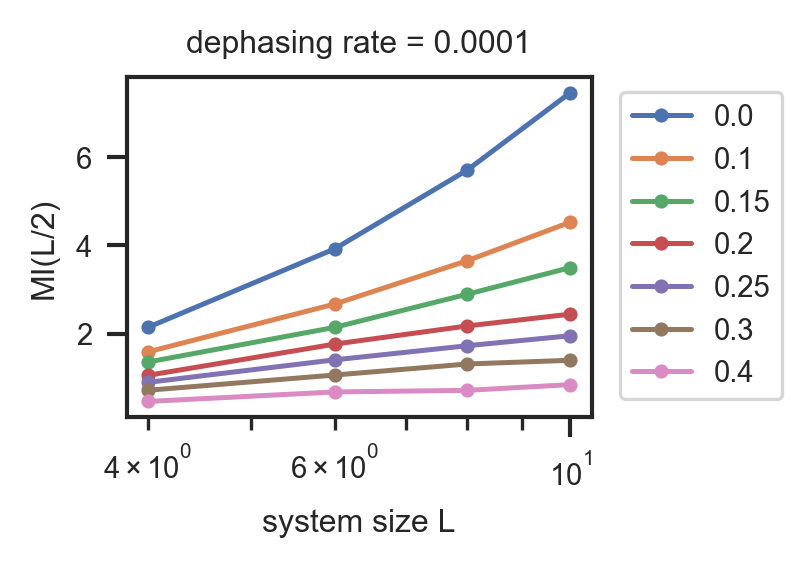

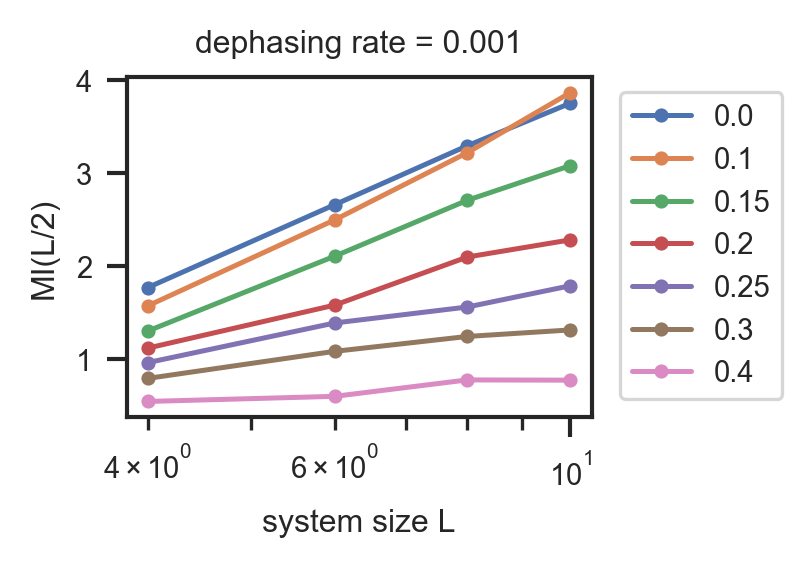

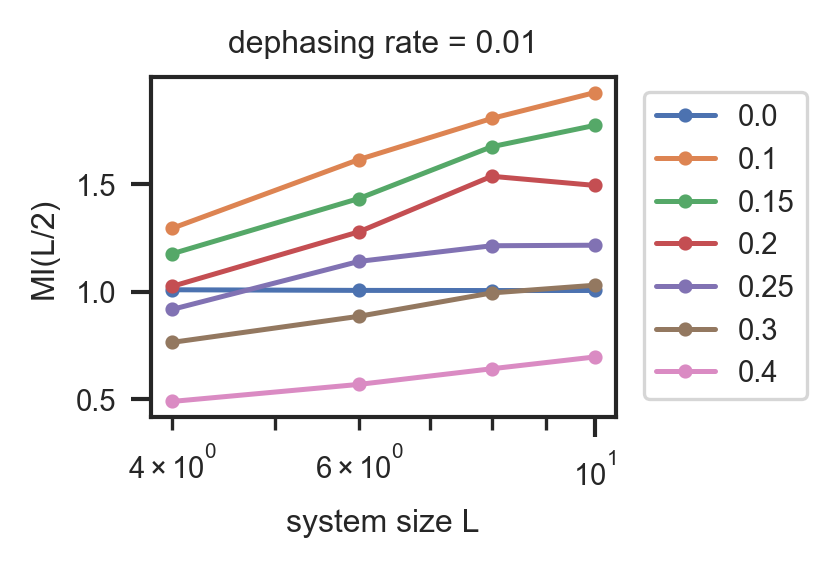

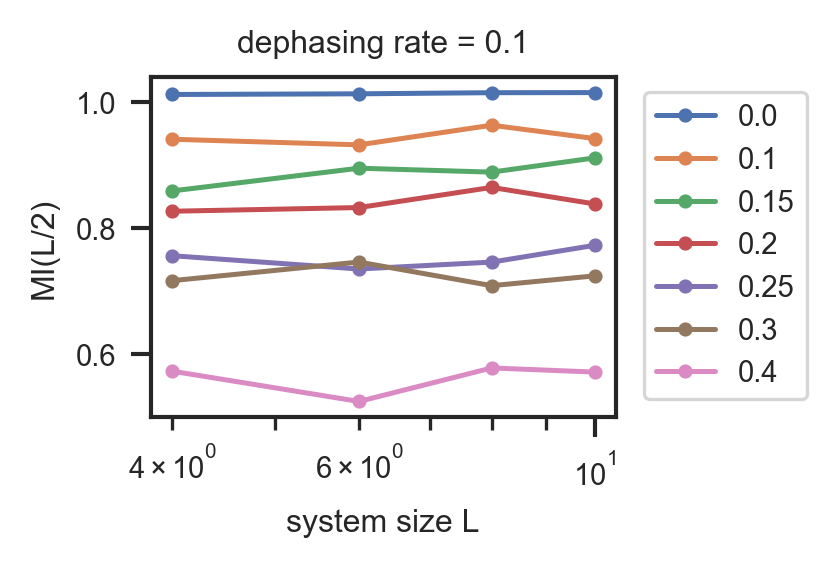

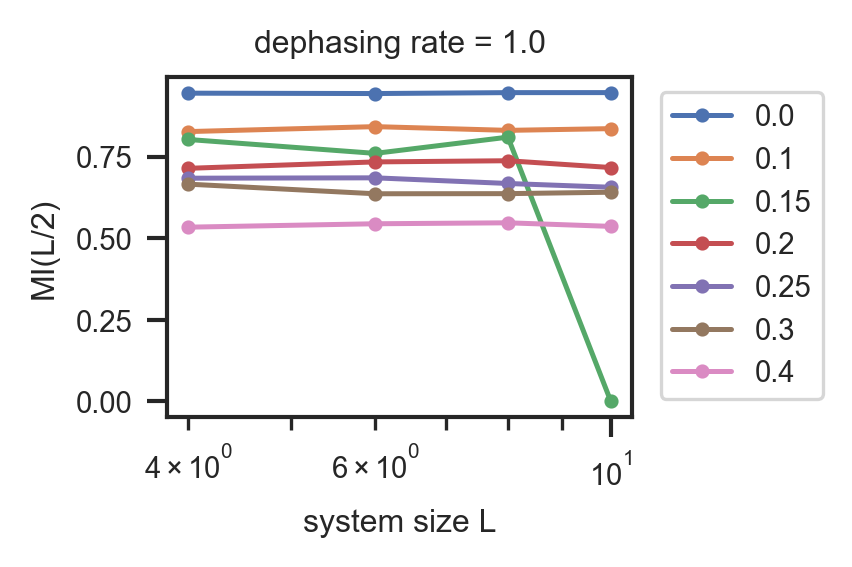

In [47]:
for rate in rateList:
    plt.figure()
    for prob in probList:
        plt.semilogx(np.array(NList), avgedMI_steady_0[rate][prob],'.-')
        plt.xlabel('system size L')
        plt.ylabel('MI(L/2)')
        plt.title('dephasing rate = ' + str(rate))
    plt.legend(probList,bbox_to_anchor= (1.03, 1))

At dephasing rate 0.0001, p_c ~ 0.2 (eyeballed) but 0.15 works better for the second type of collapse.

At dephasing rate 0.001, p_c ~ 0.2 (eyeballed) (0 probability of msm crosses that of 0.1)

At dephasing rate 0.01, p_c ~ 0.15 (eyeballed) (0 probability of msm = FLAT, area law)


In [51]:
[alpha_p, intercept] = np.polyfit(np.log(NList), np.array(avgedMI_steady_0[0.0001][0.2]).astype(float), 1)
print(alpha_p, intercept)


1.523488731918972 -1.0215212234622657


In [191]:
np.sqrt(0.0005)

0.022360679774997897

In [66]:
avgedMI_steady_0[0.0001][probMsm]

array([2.13891205, 3.92073822, 5.7068811 , 7.46033882])

In [141]:
avgedMI_inN00001={}
for (ind, N) in enumerate(NList):
    if N != 10:
        avgedMI_inN00001[N] = np.zeros(len(probList))
        for (idx,probMsm) in enumerate(probList):
            avgedMI_inN00001[N][idx] = avgedMI_steady_0[0.0001][probMsm][ind]
            
    else:
        idx = 0
        avgedMI_inN00001[N] = np.zeros(len(probList)-1)
        for probMsm in probList:
            if probMsm != 0.05:
                avgedMI_inN00001[N][idx] = avgedMI_steady_0[0.0001][probMsm][ind]
                idx +=1 

Text(0, 0.5, '$I(A:\\overline{A})/L^{\\gamma}$')

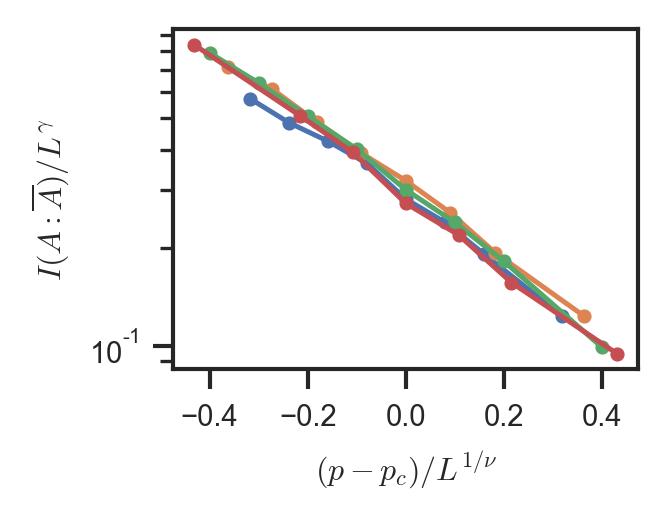

In [183]:
# Spoz the following for dissipation rate 1e-4:
p_c = 0.2 
nu = 3 # same exponent in 
gamma = .95 

probListForN10 = np.array([0.0, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4]).astype(float)

for N in NList:
    if N !=10:
        orderParam = (np.array(probList).astype(float) - p_c) * N ** (1/nu)
        plt.semilogy(orderParam, avgedMI_inN00001[N] / N ** gamma ,'.-')
    else: 
        orderParam = (np.array(probListForN10) - p_c) * N ** (1/nu)
        plt.semilogy(orderParam, avgedMI_inN00001[N] / N ** gamma ,'.-')
        
plt.xlabel(r'$(p-p_c)/L^{1/\nu}$')
plt.ylabel(r'$I(A:\overline{A})/L^{\gamma}$')


In [165]:
MI_diff_inN00001={}

# all probabilities except for p_c = 0.2
probFitList = np.array([0.0, 0.05, 0.1, 0.2, 0.25, 0.3, 0.4]).astype(float)

for (ind, N) in enumerate(NList):
    if N != 10:
        MI_diff_inN00001[N] = np.zeros(len(probFitList))
        for (idx,probMsm) in enumerate(probFitList):
            MI_diff_inN00001[N][idx] = avgedMI_steady_0[0.0001][probMsm][ind] - avgedMI_steady_0[0.0001][0.15][ind]         
    else:
        idx = 0
        MI_diff_inN00001[N] = np.zeros(len(probFitList)-1)
        for probMsm in probFitList:
            if probMsm != 0.05:
                MI_diff_inN00001[N][idx] = avgedMI_steady_0[0.0001][probMsm][ind] - avgedMI_steady_0[0.0001][0.15][ind]         
                idx +=1 
                

In [190]:
np.sin(np.arctan((5/(np.sqrt(34)-2)-1)**(1/4)))**2

0.3558409655998258

In [192]:
1/280

0.0035714285714285713

Text(0, 0.5, '$I_{A:\\overline{A}}(p)-I_{A:\\overline{A}}(p_c)$')

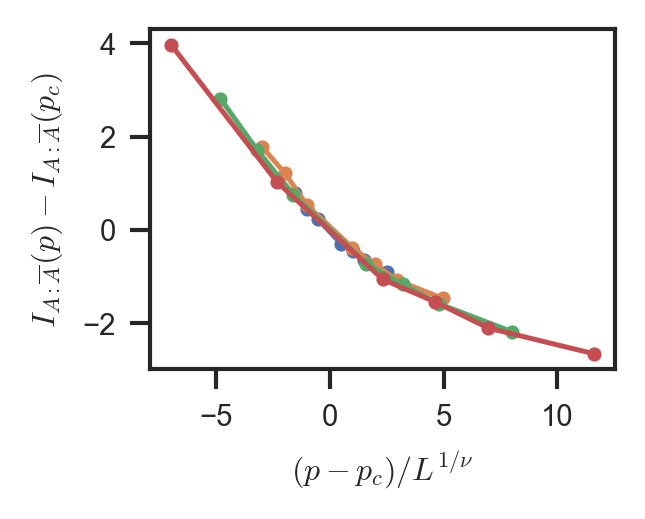

In [174]:
# Spoz the following for dissipation rate 1e-4:
p_c = 0.15
nu = 0.6

probListForN10 = np.array([0.0, 0.1, 0.2, 0.25, 0.3, 0.4]).astype(float)

for N in NList:
    if N !=10:
        orderParam = (np.array(probFitList).astype(float) - p_c) * N ** (1/nu)
        plt.plot(orderParam, MI_diff_inN00001[N],'.-')
    else: 
        orderParam = (np.array(probListForN10) - p_c) * N ** (1/nu)
        plt.plot(orderParam, MI_diff_inN00001[N], '.-')
        
plt.xlabel(r'$(p-p_c)/L^{1/\nu}$')
plt.ylabel(r'$I_{A:\overline{A}}(p)-I_{A:\overline{A}}(p_c)$')


OMFG.



Onto the next dissipation rate, the data is much noisier.

In [102]:
avgedMI_inN0001={}
for (ind, N) in enumerate(NList):
    if N != 10:
        avgedMI_inN0001[N] = np.zeros(len(probList[1:]))
        for (idx,probMsm) in enumerate(probList[1:]):
            avgedMI_inN0001[N][idx] = avgedMI_steady_0[0.001][probMsm][ind]        
    else:
        idx = 0
        avgedMI_inN0001[N] = np.zeros(len(probList[1:])-1)
        for probMsm in probList[1:]:
            if probMsm != 0.05:
                avgedMI_inN0001[N][idx] = avgedMI_steady_0[0.001][probMsm][ind]
                idx +=1 

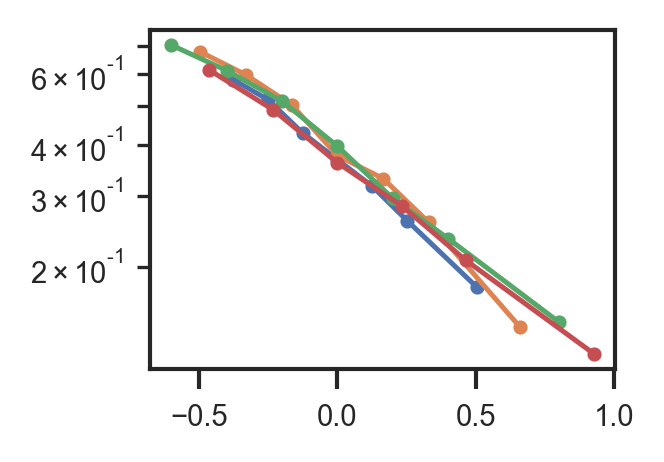

In [134]:
# Spoz the following for dissipation rate 1e-3, except for the one without any measurement:
p_c = 0.2 
# Not sure if this is still the right p_c to look at since the curves are not completely on top of each other
nu = 1.5
gamma = 0.8 

probListForN10 = [0.1, 0.15, 0.2, 0.25, 0.3, 0.4]

for N in NList:
    if N !=10:
        orderParam = (np.array(probList[1:]) - p_c) * N ** (1/nu)
        plt.semilogy(orderParam, avgedMI_inN0001[N] / N ** gamma ,'.-')
    else: 
        orderParam = (np.array(probListForN10) - p_c) * N ** (1/nu)
        plt.semilogy(orderParam, avgedMI_inN0001[N] / N ** gamma ,'.-')
        